# Optimal Transport in linear ICA

#### Try to find a case where the FastICA assumption $E(XG’(X)-G’’(X))!=0$ where G is a contrast function (logcosh), does not hold and OT ICA performs. 

### Engineering a Mathematical Trap for FastICA (Assumption A.5)

To mathematically prove the limitations of FastICA's reliance on parametric summaries, we can engineer a specific distribution that violates its core convergence requirement, known as **Assumption A.5**. 

Assumption A.5 requires that the generalized kurtosis for the chosen contrast function $g(s)$ must not be zero:
$$E[s g(s) - g'(s)] \neq 0$$

For FastICA's default `logcosh` contrast function, the derivatives are $g(s) = \tanh(s)$ and $g'(s) = 1 - \tanh^2(s)$. We want to find a distribution where this expectation is exactly $0$.

#### 1. Defining the Discrete Distribution
We define a symmetric discrete distribution that takes only three values $S \in \{-b, 0, b\}$ with corresponding probabilities $\{p, 1-2p, p\}$.

#### 2. The Unit Variance Constraint
Standard ICA requires the independent sources to have unit variance ($E[S^2] = 1$). 
$$E[S^2] = p(-b)^2 + (1-2p)(0)^2 + p(b)^2 = 2pb^2$$
Setting this to $1$, we can express the probability $p$ entirely in terms of the value $b$:
$$p = \frac{1}{2b^2}$$

#### 3. Forcing the A.5 Failure Condition
We substitute our discrete distribution into the FastICA failure condition $E[s \tanh(s) - (1 - \tanh^2(s))] = 0$:

$$2p \left[ b \tanh(b) - (1 - \tanh^2(b)) \right] + (1-2p) \left[ 0 - (1 - 0) \right] = 0$$

Simplifying the equation:
$$2p \left[ b \tanh(b) - 1 + \tanh^2(b) \right] - (1 - 2p) = 0$$
$$2p \left[ b \tanh(b) + \tanh^2(b) \right] - 2p - 1 + 2p = 0$$
$$2p \left[ b \tanh(b) + \tanh^2(b) \right] = 1$$

#### 4. The Final Root Equation
Substituting $2p = \frac{1}{b^2}$ into the simplified equation yields a single-variable root-finding problem:
$$\frac{1}{b^2} \left[ b \tanh(b) + \tanh^2(b) \right] = 1$$
$$b \tanh(b) + \tanh^2(b) - b^2 = 0$$

By solving for $b$ numerically, we find the exact signal amplitude (and corresponding probability $p$) that makes the data mathematically invisible to FastICA's Newton-step optimizer.

In [1]:
import numpy as np
import torch
import pandas as pd
import time
from sklearn.decomposition import FastICA
from joblib import Parallel, delayed
from tqdm.notebook import tqdm
from scipy.optimize import root_scalar
import seaborn as sns
import matplotlib.pyplot as plt

from wasserstein_ica import WassersteinICA

In [2]:
# ==========================================
# 1. The Mathematical Trap Generator
# ==========================================

def find_fastica_trap_b():
    """Finds the exact value of b that makes generalized kurtosis 0 for logcosh."""
    def target_func(b):
        return b * np.tanh(b) + np.tanh(b)**2 - b**2
    
    # We know the root is somewhere between 1.0 and 2.0
    sol = root_scalar(target_func, bracket=[1.0, 2.0], method='brentq')
    return sol.root

# Calculate our fastica trap parameters
MAGIC_B = find_fastica_trap_b()
MAGIC_P = 1.0 / (2 * MAGIC_B**2)
print(f"Calculated Trap Value b: {MAGIC_B:.5f}")
print(f"Calculated Probability p: {MAGIC_P:.5f}")

Calculated Trap Value b: 1.44891
Calculated Probability p: 0.23817


In [3]:
def generate_discrete_trap(n_dim, n_samples, seed=None):
    if seed is not None:
        np.random.seed(seed)
        torch.manual_seed(seed)
        
    # Generate the source signals based on our exact probabilities
    # Choices: -b, 0, b. Probabilities: p, 1-2p, p
    choices = [-MAGIC_B, 0.0, MAGIC_B]
    probs = [MAGIC_P, 1.0 - 2*MAGIC_P, MAGIC_P]
    
    sources = []
    for _ in range(n_dim):
        s = np.random.choice(choices, size=n_samples, p=probs)
        sources.append(s)
    S = np.stack(sources)
    
    # Well-conditioned mixing matrix
    cond_num = 1000
    while cond_num > 100:
        A = np.random.randn(n_dim, n_dim)
        cond_num = np.linalg.cond(A)
        
    X = A @ S
    return torch.tensor(X, dtype=torch.float32), A

def amari_error(W_est, A_true):
    if W_est is None or np.any(np.isnan(W_est)):
        return np.nan
    P = np.abs(W_est @ A_true)
    n = P.shape[0]
    row_sum = np.sum(P, axis=1)
    row_max = np.max(P, axis=1)
    term1 = np.sum((row_sum / row_max) - 1)
    col_sum = np.sum(P, axis=0)
    col_max = np.max(P, axis=0)
    term2 = np.sum((col_sum / col_max) - 1)
    return (term1 + term2) / (2 * n)

In [ ]:
# ==========================================
# 2. Parallel Worker Function
# ==========================================

def run_trap_trial(dim, trial, n_samples):
    torch.set_num_threads(1) 
    trial_results = []

    # Detect GPU inside the worker
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    X_torch, A_true = generate_discrete_trap(n_dim=dim, n_samples=n_samples, seed=trial)
    X_torch = X_torch.to(device)
    
    # Pull back to CPU for Scikit-learn's FastICA
    X_np = X_torch.cpu().numpy()
    
    # --- FastICA ---
    try:
        fast_ica = FastICA(n_components=dim, max_iter=2000, tol=1e-4, random_state=trial)
        fast_ica.fit(X_np.T)
        W_fast_total = fast_ica.components_
        score_fast = amari_error(W_fast_total, A_true)
    except Exception as e:
        score_fast = np.nan
        
    trial_results.append({'Dimension': dim, 'Method': 'FastICA', 'Amari Error': score_fast})
    
    # --- W-ICA (Stiefel) ---
    try:
        ica = WassersteinICA(X_torch)
        ica.whiten()
        W_white_np = ica.W_white.cpu().numpy()
        
        extracted_ws = []
        n_restarts = dim * 4 if dim * 4 < 150 else 150
        for _ in range(dim):
            prev = torch.stack(extracted_ws) if extracted_ws else None
            w, _ = ica.optimize_wasserstein2(prev_components=prev, max_iter=200, n_restarts=n_restarts)
            extracted_ws.append(w)
        W_deflation_init = torch.stack(extracted_ws)
        
        W_stiefel_unmixed = ica.optimize_symmetric(
            n_components=dim, max_iter=200, lr=0.5, init_w=W_deflation_init, optimizer='stiefel'
        )
        W_wass_total = W_stiefel_unmixed.cpu().numpy() @ W_white_np
        score_wass = amari_error(W_wass_total, A_true)
        
    except Exception as e:
        score_wass = np.nan
        
    trial_results.append({'Dimension': dim, 'Method': 'W-ICA (Stiefel)', 'Amari Error': score_wass})
    
    return trial_results

In [ ]:
# ==========================================
# 3. Main Execution
# ==========================================
DIMENSIONS = [10, 20, 30]
N_SAMPLES = 250000
N_TRIALS = 5

print(f"--- FastICA Assumption A.5 Trap Showdown ---")

tasks = [(dim, trial, N_SAMPLES) for dim in DIMENSIONS for trial in range(N_TRIALS)]

results_nested = Parallel(n_jobs=12)(
    delayed(run_trap_trial)(dim, trial, n_samples) 
    for dim, trial, n_samples in tqdm(tasks, desc="Running Trap Trials")
)

results = [item for sublist in results_nested for item in sublist]
df = pd.DataFrame(results)

--- FastICA Assumption A.5 Trap Showdown ---


Running Trap Trials:   0%|          | 0/15 [00:00<?, ?it/s]

/home/ajha/Downloads/temp_mt/ot_in_linear_ica/wica_env/lib/python3.12/site-packages/torch/cuda/__init__.py:716: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")
/home/ajha/Downloads/temp_mt/ot_in_linear_ica/wica_env/lib/python3.12/site-packages/torch/cuda/__init__.py:716: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")
/home/ajha/Downloads/temp_mt/ot_in_linear_ica/wica_env/lib/python3.12/site-packages/torch/cuda/__init__.py:716: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")
/home/ajha/Downloads/temp_mt/ot_in_linear_ica/wica_env/lib/python3.12/site-packages/torch/cuda/__init__.py:716: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")
/home/ajha/Downloads/temp_mt/ot_in_linear_ica/wica_env/lib/python3.12/site-packages/torch/cuda/__init__.py:716: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")
/home/ajha/Downloads/temp_mt/ot_in_linear_ica/wica_env/lib/p

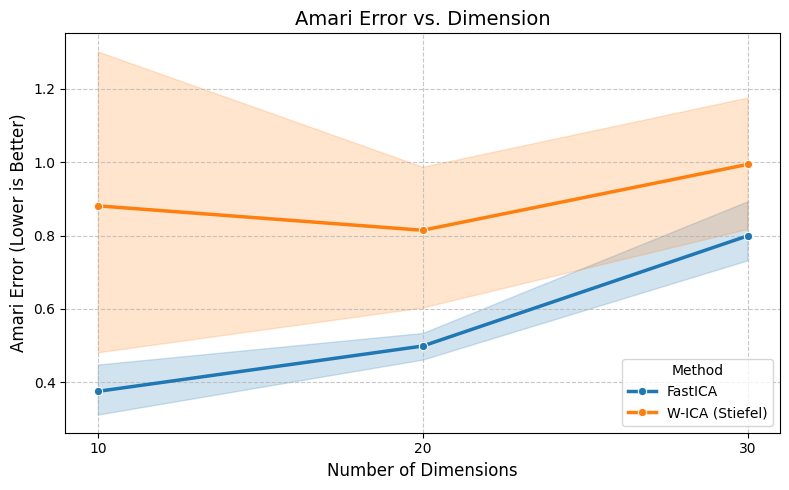

Method,FastICA,W-ICA (Stiefel)
Dimension,,
10,0.3753,0.8812
20,0.4988,0.8146
30,0.7992,0.9941


In [6]:
# ==========================================
# 4. Plotting the Results
# ==========================================
plt.figure(figsize=(8, 5))
sns.lineplot(data=df, x='Dimension', y='Amari Error', hue='Method', marker='o', linewidth=2.5)
plt.title("Amari Error vs. Dimension", fontsize=14)
plt.ylabel("Amari Error (Lower is Better)", fontsize=12)
plt.xlabel("Number of Dimensions", fontsize=12)
plt.xticks(DIMENSIONS)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

display(df.groupby(['Dimension', 'Method'])['Amari Error'].mean().unstack().round(4))

### Engineering the "Clipped Uniform" Trap (Assumption A.5)

To test FastICA's A.5 assumption in a more physically realistic scenario (such as a saturated sensor or overloaded amplifier), we construct a **Clipped Uniform** distribution.

#### 1. Defining the Clipped Distribution
We begin with a continuous uniform distribution on the interval $[-c, c]$, and apply a hard clipping threshold at $[-b, b]$ (where $0 < b < c$). 
The resulting distribution has:
* A continuous uniform probability density function (PDF) of $\frac{1}{2c}$ inside the interval $(-b, b)$.
* Dirac delta point masses at exactly $-b$ and $b$, each holding the clipped probability mass of $p = \frac{c-b}{2c}$.

#### 2. The Unit Variance Constraint
To satisfy standard ICA scaling, the variance must equal 1 ($E[S^2] = 1$):
$$E[S^2] = \int_{-b}^{b} x^2 \frac{1}{2c} dx + 2 \left( \frac{c-b}{2c} \right) b^2 = 1$$

Evaluating the integral and solving for $c$ yields a direct relationship between the original boundary $c$ and the clipping threshold $b$:
$$c = \frac{2b^3}{3(b^2 - 1)}$$
*(Note: To ensure $c > b > 0$, the clipping threshold must fall in the range $1 < b < \sqrt{3}$.)*

#### 3. Forcing the A.5 Failure Condition
We define the A.5 failure condition $h(x) = x \tanh(x) - 1 + \tanh^2(x)$. To break FastICA's `logcosh` contrast function, the expected value must equal exactly zero ($E[h(S)] = 0$).

We split the expectation into its continuous and discrete components:
$$E[h(S)] = \int_{-b}^{b} h(x) \frac{1}{2c} dx + 2 \left( \frac{c-b}{2c} \right) h(b) = 0$$

By multiplying both sides by $c$ (since $c > 0$) and utilizing symmetry, we arrive at the final root-finding equation:
$$\int_{0}^{b} \left( x \tanh(x) - 1 + \tanh^2(x) \right) dx + (c - b) \left( b \tanh(b) - 1 + \tanh^2(b) \right) = 0$$

Because there is no closed-form elementary antiderivative for $x \tanh(x)$, we solve this integral and find the root for $b$ numerically.

In [7]:
from scipy.integrate import quad

In [8]:
# ==========================================
# 1. The Continuous Trap Generator
# ==========================================

def find_clipped_trap_params():
    """Numerically finds the optimal clipping threshold b and uniform bound c."""
    def h(x):
        return x * np.tanh(x) - 1.0 + np.tanh(x)**2
        
    def target_func(b):
        # Variance constraint determines c
        c = (2 * b**3) / (3 * (b**2 - 1))
        # Continuous integral part
        integral_val, _ = quad(h, 0, b)
        # Discrete clipped edges part
        discrete_val = (c - b) * h(b)
        return integral_val + discrete_val

    # The bounds 1.001 to 1.73 (approx sqrt(3)) satisfy c > b > 0
    sol = root_scalar(target_func, bracket=[1.001, 1.73], method='brentq')
    b_opt = sol.root
    c_opt = (2 * b_opt**3) / (3 * (b_opt**2 - 1))
    return b_opt, c_opt

CLIP_B, UNIFORM_C = find_clipped_trap_params()
print(f"Calculated Clipping Threshold b: {CLIP_B:.5f}")
print(f"Calculated Original Uniform Bound c: {UNIFORM_C:.5f}")

ValueError: f(a) and f(b) must have different signs

In [ ]:
def generate_clipped_trap(n_dim, n_samples, seed=None):
    if seed is not None:
        np.random.seed(seed)
        torch.manual_seed(seed)
        
    # Generate the base uniform sources U[-c, c]
    S = np.random.uniform(-UNIFORM_C, UNIFORM_C, size=(n_dim, n_samples))
    
    # Apply the hard clipping at [-b, b]
    S = np.clip(S, -CLIP_B, CLIP_B)
    
    # Well-conditioned mixing matrix
    cond_num = 1000
    while cond_num > 100:
        A = np.random.randn(n_dim, n_dim)
        cond_num = np.linalg.cond(A)
        
    X = A @ S
    return torch.tensor(X, dtype=torch.float32), A

In [ ]:
# ==========================================
# 2. Parallel Worker Function
# ==========================================

def run_clipped_trap_trial(dim, trial, n_samples):
    torch.set_num_threads(1) 
    trial_results = []
    
    X_torch, A_true = generate_clipped_trap(n_dim=dim, n_samples=n_samples, seed=trial)
    X_np = X_torch.numpy()
    
    # --- FastICA ---
    try:
        fast_ica = FastICA(n_components=dim, max_iter=2000, tol=1e-4, random_state=trial)
        fast_ica.fit(X_np.T)
        W_fast_total = fast_ica.components_
        score_fast = amari_error(W_fast_total, A_true)
    except Exception:
        score_fast = np.nan
        
    trial_results.append({'Dimension': dim, 'Method': 'FastICA', 'Amari Error': score_fast})
    
    # --- W-ICA (Stiefel) ---
    try:
        ica = WassersteinICA(X_torch)
        ica.whiten()
        W_white_np = ica.W_white.cpu().numpy()
        
        extracted_ws = []
        n_restarts = dim * 4 if dim * 4 < 150 else 150
        for _ in range(dim):
            prev = torch.stack(extracted_ws) if extracted_ws else None
            w, _ = ica.optimize_wasserstein2(prev_components=prev, max_iter=200, n_restarts=n_restarts)
            extracted_ws.append(w)
        W_deflation_init = torch.stack(extracted_ws)
        
        W_stiefel_unmixed = ica.optimize_symmetric(
            n_components=dim, max_iter=200, lr=0.5, init_w=W_deflation_init, optimizer='stiefel'
        )
        W_wass_total = W_stiefel_unmixed.cpu().numpy() @ W_white_np
        score_wass = amari_error(W_wass_total, A_true)
        
    except Exception:
        score_wass = np.nan
        
    trial_results.append({'Dimension': dim, 'Method': 'W-ICA (Stiefel)', 'Amari Error': score_wass})
    
    return trial_results

In [ ]:
# ==========================================
# 3. Main Execution & Plotting
# ==========================================
DIMENSIONS = [10, 20, 30]
N_SAMPLES = 5000
N_TRIALS = 5

print(f"--- FastICA Clipped Uniform Trap Showdown ---")

tasks = [(dim, trial, N_SAMPLES) for dim in DIMENSIONS for trial in range(N_TRIALS)]

results_nested = Parallel(n_jobs=12)(
    delayed(run_clipped_trap_trial)(dim, trial, n_samples) 
    for dim, trial, n_samples in tqdm(tasks, desc="Running Clipped Trap Trials")
)

results = [item for sublist in results_nested for item in sublist]
df_clipped = pd.DataFrame(results)

In [ ]:
plt.figure(figsize=(8, 5))
sns.lineplot(data=df_clipped, x='Dimension', y='Amari Error', hue='Method', marker='o', linewidth=2.5)
plt.title("Amari Error vs. Dimension\n(The Clipped Uniform A.5 Trap)", fontsize=14)
plt.ylabel("Amari Error (Lower is Better)", fontsize=12)
plt.xlabel("Number of Dimensions", fontsize=12)
plt.xticks(DIMENSIONS)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

display(df_clipped.groupby(['Dimension', 'Method'])['Amari Error'].mean().unstack().round(4))